# 🤖 **Build Your First Agent in Pure Python**

### **But, why?**

Because it's good to look under the abstrations every once in a while.

In [ ]:
!pip install groq python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 9.9 MB/s eta 0:00:00


## Setting up Groq for LLM Inference

**💡What is Groq?**

A platform that serves LLMs and provides access to OpenSource models in their freetier

---

**💡How to access models on Groq?**
 1. Visit : https://console.groq.com/keys
 2. Create an account using your email ID
 3. Click on the "Create API Key" button and enter a name for the key (we are using "CB_LangChain"
 4. Copy the generated key and paste it some where save
 5. Run the code below and paste the groq API Key in the text box

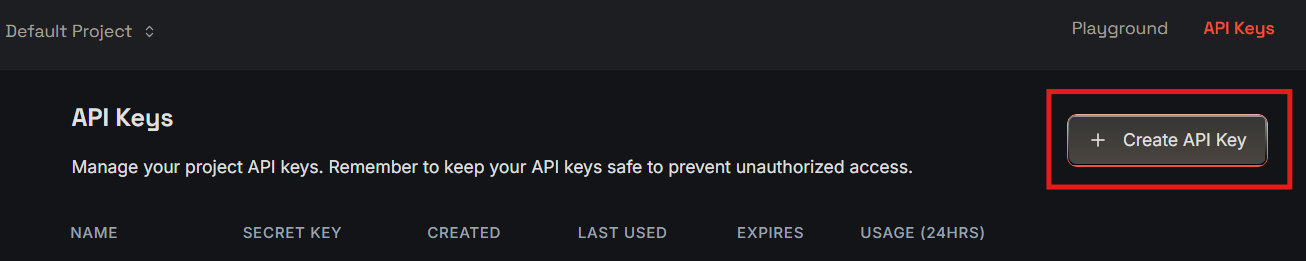

In [ ]:
import getpass
import os

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

Enter your Groq API key: ··········


In [ ]:
import os
from groq import Groq

assert os.getenv("GROQ_API_KEY"), "GROQ_API_KEY missing — check your .env file"
print("✅ API key found")

client = Groq()
ping = client.chat.completions.create(
    model="openai/gpt-oss-20b",
    messages=[{"role": "user", "content": "Reply with the single word: pong"}],
    temperature=0,
)
print("✅ Groq reachable →", ping.choices[0].message.content)

✅ API key found
✅ Groq reachable → pong


In [ ]:
MODEL = "openai/gpt-oss-20b"

**LLMs have limited capability on their own.**

In [ ]:
def ask(question: str) -> str:
    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": question}],
        temperature=0,
    )
    choice = response.choices[0]
    text   = (choice.message.content or "").strip()
    return text or f"(empty reply — finish_reason={choice.finish_reason!r}; re-run the cell)"

print("🤖 LLM (maths)   :", ask("What is 482912 * 73649? Reply with just the number."))
print("🧮 Python        :", 482912 * 73649)
print()
print("🤖 LLM (weather) :", ask("What is the weather in Ahmedabad right now?"))

🤖 LLM (maths)   : 35565985888
🧮 Python        : 35565985888

🤖 LLM (weather) : I’m sorry, but I don’t have access to real‑time data, so I can’t give you the current weather in Ahmedabad.  

You can quickly check the latest conditions by:

- Visiting a weather website such as **weather.com**, **AccuWeather**, or **BBC Weather** and searching for “Ahmedabad.”
- Using a weather app on your phone (e.g., the built‑in Weather app on iOS/Android, or a third‑party app like Weather Underground).
- Asking a smart assistant (Google Assistant, Siri, Alexa) with a voice command like “What’s the weather in Ahmedabad right now?”

If you’d like, I can show you how to set up a simple script that pulls the current weather from an API (e.g., OpenWeatherMap) so you can get it programmatically. Let me know if that would be helpful!


## **What is an AI Agent?**

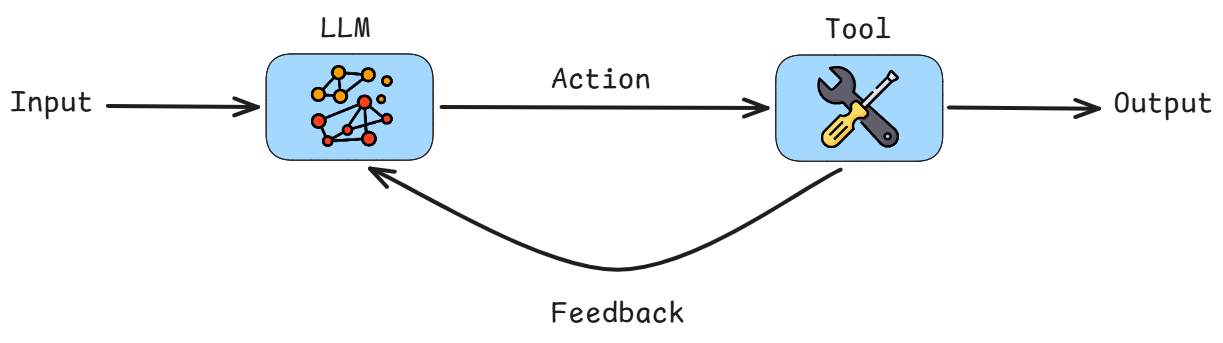

## **What are Tools?**

In [ ]:
WEATHER = {
    "ahmedabad": "34°C, sunny",
    "pune":      "28°C, partly cloudy",
    "london":    "15°C, light rain",
    "tokyo":     "22°C, clear",
}

def get_weather(city):
    key = city.strip().lower()
    if key not in WEATHER:
        return f"No weather data for {city}."
    return f"{city.title()}: {WEATHER[key]}"

def calculator(expression):
    allowed = set("0123456789+-*/(). ")
    if not set(expression) <= allowed:
        return "Error: only numbers and + - * / ( ) are allowed."
    return str(eval(expression))

print(get_weather("Ahmedabad"))
print(calculator("(34 - 28) * 9 / 5"))
print("✅ Two tools work as normal Python")

Ahmedabad: 34°C, sunny
10.8
✅ Two tools work as normal Python


In [ ]:
calculator_tool = {
    "name":        "calculator",
    "description": "Do arithmetic. The input is an expression like '(34 - 28) * 9 / 5'.",
    "parameters":  {"expression": "string"},
    "function":    calculator,
}

weather_tool = {
    "name":        "get_weather",
    "description": "Get the current weather for a city.",
    "parameters":  {"city": "string"},
    "function":    get_weather,
}

TOOLS = [calculator_tool, weather_tool]

print("✅ Tools ready:", [t["name"] for t in TOOLS])

✅ Tools ready: ['calculator', 'get_weather']


In [ ]:
def to_schema(tool):
    return {
        "type": "function",
        "function": {
            "name":        tool["name"],
            "description": tool["description"],
            "parameters": {
                "type":       "object",
                "properties": {p: {"type": t} for p, t in tool["parameters"].items()},
                "required":   list(tool["parameters"]),
            },
        },
    }

In [ ]:
PY_TO_JSON = {str: "string", int: "integer", float: "number", bool: "boolean"}

In [ ]:
response = client.chat.completions.create(
    model=MODEL,
    messages=[{"role": "user", "content": "What's the weather in Ahmedabad?"}],
    tools=[to_schema(t) for t in TOOLS],
    temperature=0,
)

message = response.choices[0].message
print("Text reply :", message.content)
for call in message.tool_calls or []:
    print("Tool asked :", call.function.name, call.function.arguments)

Text reply : None
Tool asked : get_weather {"city":"Ahmedabad"}


In [ ]:
import inspect

class Tool:
    """Wraps a Python function and auto-generates its LLM-facing schema."""

    def __init__(self, fn):
        self.fn          = fn
        self.name        = fn.__name__
        self.description = inspect.getdoc(fn) or ""

        properties, required = {}, []
        for pname, param in inspect.signature(fn).parameters.items():
            properties[pname] = {"type": PY_TO_JSON.get(param.annotation, "string")}
            if param.default is inspect.Parameter.empty:   # no default → required
                required.append(pname)

        self.schema = {
            "type": "function",
            "function": {
                "name":        self.name,
                "description": self.description,
                "parameters":  {"type": "object", "properties": properties, "required": required},
            },
        }

    def __call__(self, *args, **kwargs):
        return self.fn(*args, **kwargs)

    def run(self, args: dict) -> str:
        """Execute with model-supplied args. Errors become observations, not crashes."""
        try:
            return str(self.fn(**args))
        except Exception as e:
            return f"Error: {type(e).__name__}: {e}"

def tool(fn):
    return Tool(fn)

print("✅ Tool class and @tool decorator ready")

✅ Tool class and @tool decorator ready


In [ ]:
@tool
def get_weather(city):
    """Get the current weather for a city."""
    key = city.strip().lower()
    if key not in WEATHER:
        return f"No weather data for {city}."
    return f"{city.title()}: {WEATHER[key]}"

@tool
def calculator(expression):
    """Do arithmetic. The input is an expression like '(34 - 28) * 9 / 5'."""
    allowed = set("0123456789+-*/(). ")
    if not set(expression) <= allowed:
        return "Error: only numbers and + - * / ( ) are allowed."
    return str(eval(expression))

In [ ]:
TOOLS = [calculator, get_weather]

### 🔁 **The ReAct Loop**

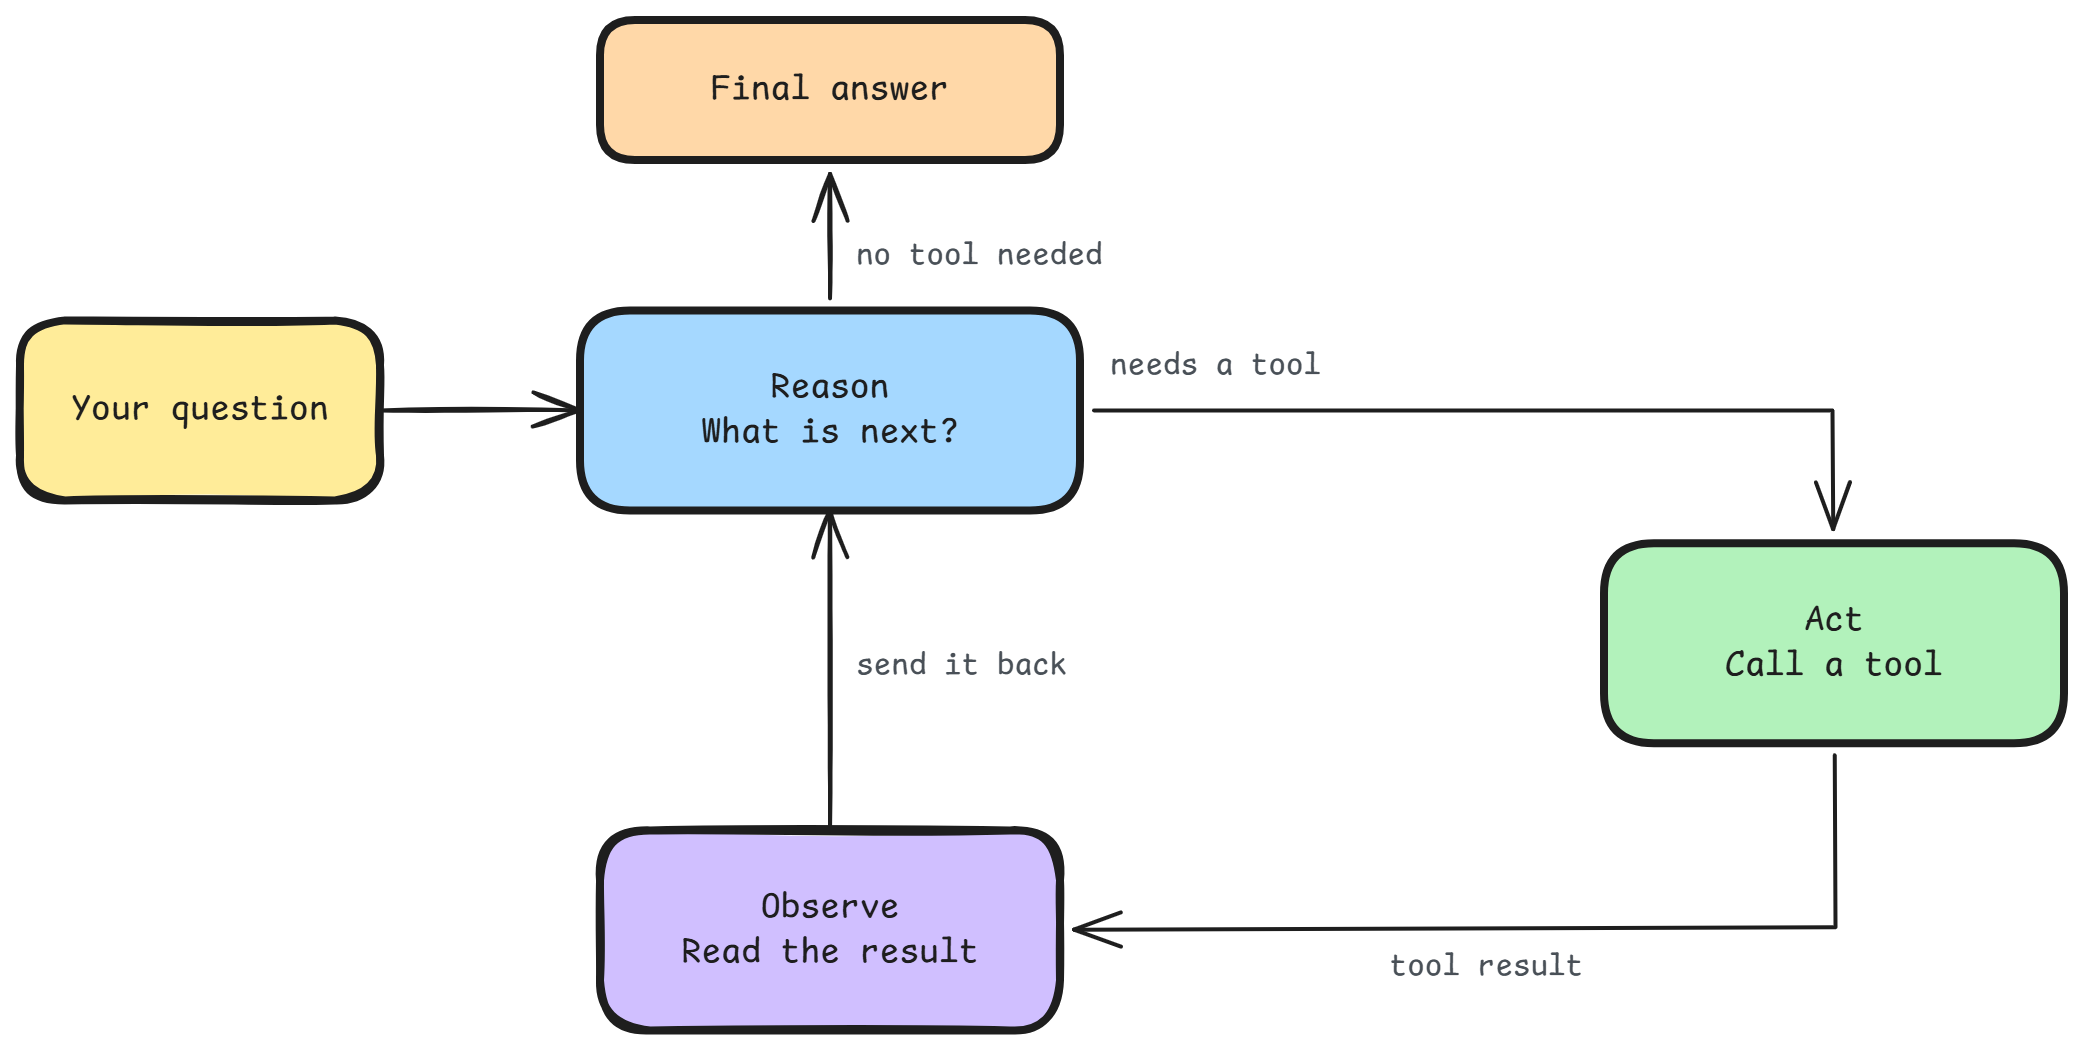

In [ ]:
import json

def run_agent(messages, tools, max_steps=6, verbose=True):
    schemas    = [t.schema for t in tools]
    registry   = {t.name: t for t in tools}
    tools_used = []

    for step in range(1, max_steps + 1):

        #1. Ask the LLM what to do next
        response = client.chat.completions.create(
            model=MODEL, messages=messages, tools=schemas, temperature=0,
        )
        msg = response.choices[0].message

        #2. Save the LLM's reply into the message list
        reply = {"role": "assistant", "content": msg.content or ""}
        if msg.tool_calls:
            reply["tool_calls"] = [
                {
                    "id":       call.id,
                    "type":     "function",
                    "function": {"name": call.function.name, "arguments": call.function.arguments},
                }
                for call in msg.tool_calls
            ]
        messages.append(reply)

        #3. No tool asked? Then this is the final answer
        if not msg.tool_calls:
            if verbose:
                print(f"🏁 Final answer: {msg.content}")
            return {"answer": msg.content or "", "tools_used": tools_used, "steps": step}

        #4. Run each tool the LLM asked for, and add the result
        for call in msg.tool_calls:
            name = call.function.name
            args = json.loads(call.function.arguments)
            if name in registry:
                result = registry[name].run(args)
            else:
                result = f"Error: unknown tool '{name}'"

            tools_used.append(name)
            messages.append({"role": "tool", "tool_call_id": call.id, "content": result})

            if verbose:
                print(f"🔧 Step {step}: {name}({args})  →  {result}")

    #Safety net: too many steps
    return {"answer": "Stopped: too many steps.", "tools_used": tools_used, "steps": max_steps}

In [ ]:
SYSTEM_PROMPT = "You are a helpful assistant. Use tools for weather and maths. Keep answers short."

messages = [
    {"role": "system", "content": SYSTEM_PROMPT},
    {"role": "user",   "content": "How much hotter is Ahmedabad than Pune, in Fahrenheit?"},
]
result = run_agent(messages, TOOLS)

🔧 Step 1: get_weather({'city': 'Ahmedabad'})  →  Ahmedabad: 34°C, sunny
🔧 Step 2: get_weather({'city': 'Pune'})  →  Pune: 28°C, partly cloudy
🏁 Final answer: Ahmedabad is about **10.8 °F hotter** than Pune.


### **Memory**

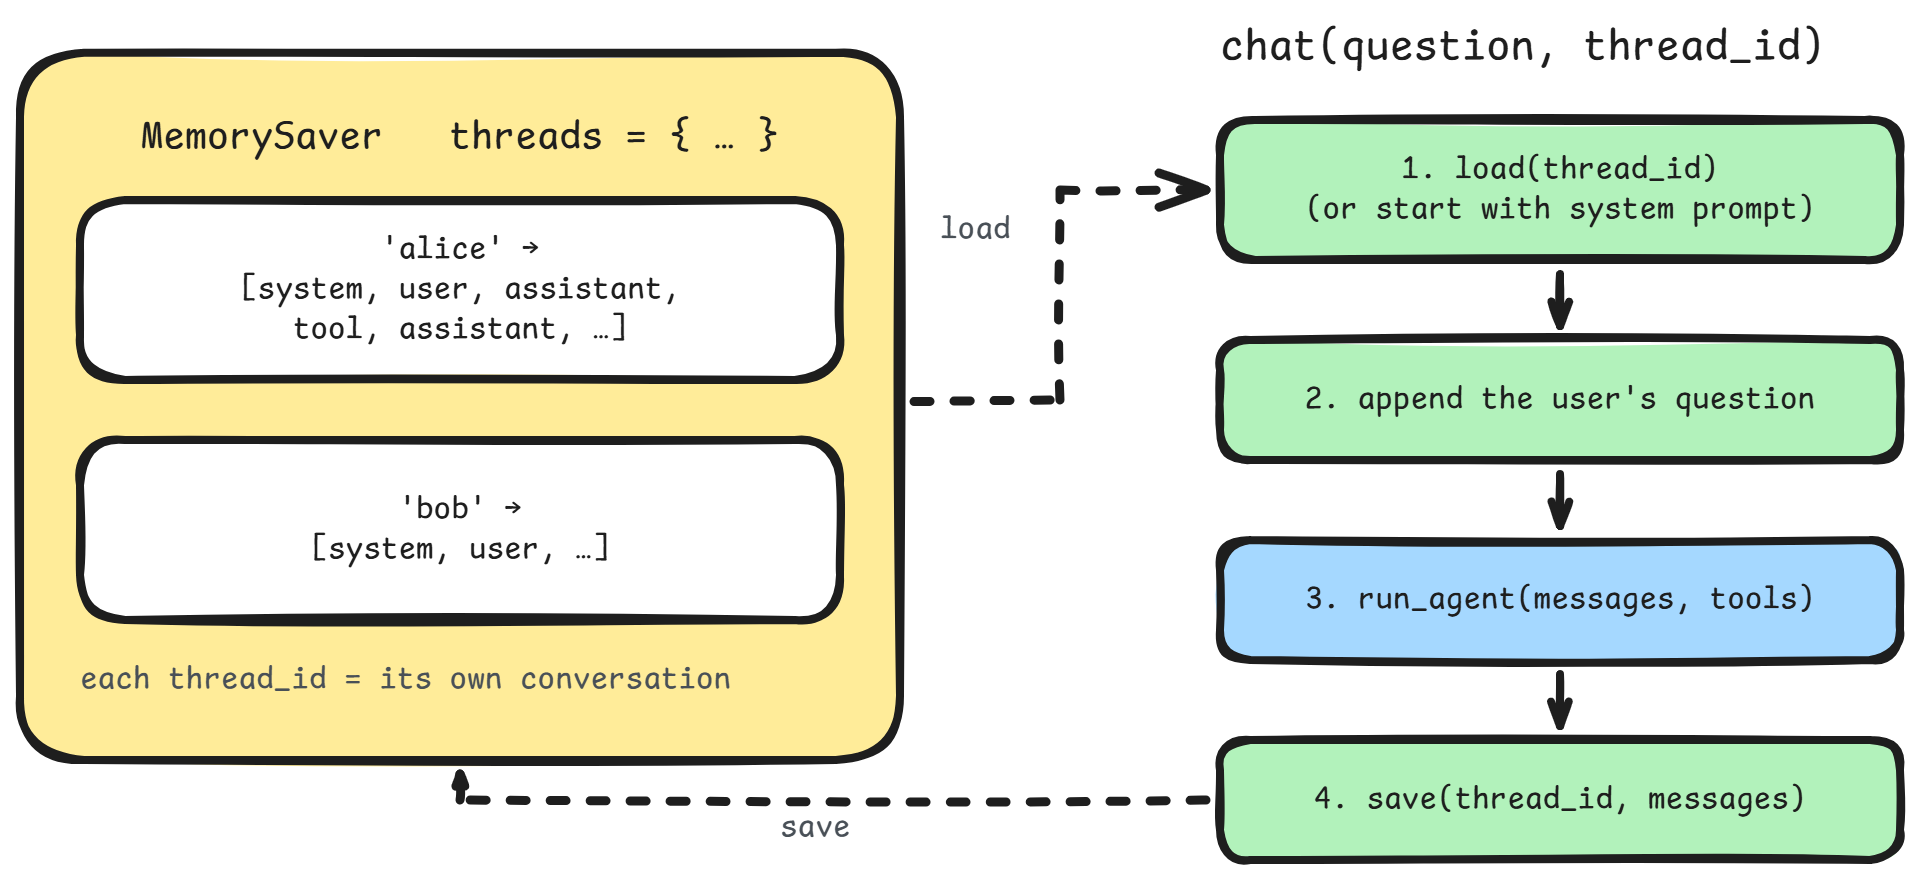

In [ ]:
def new_chat():
    return [{"role": "system", "content": SYSTEM_PROMPT}]

In [ ]:
class MemorySaver:
    """Saves conversations in a dict: thread_id → list of messages."""

    def __init__(self):
        self.threads = {}

    def load(self, thread_id):
        return list(self.threads.get(thread_id, []))    # a copy, so the saved chat stays safe

    def save(self, thread_id, messages):
        self.threads[thread_id] = list(messages)

In [ ]:
checkpointer = MemorySaver()

def chat(thread_id,question):
    messages = checkpointer.load(thread_id) or new_chat()          # 1. load (or start fresh)
    messages.append({"role": "user", "content": question})         # 2. add the new question
    result = run_agent(messages, TOOLS, verbose=False)             # 3. run the agent
    checkpointer.save(thread_id, messages)                         # 4. save everything back
    return result["answer"]

In [ ]:
print (chat("alice", "What's the weather in Ahmedabad?"))

Ahmedabad: 34 °C, sunny.


In [ ]:
print (chat("alice", "And in Pune? Which of the two is hotter?"))

Pune: 28 °C, partly cloudy.  
Ahmedabad (34 °C) is hotter than Pune.


In [ ]:
print(chat("bob",   "What was my last question?"))

Your last question was: “What was my last question?”


### **Evals**

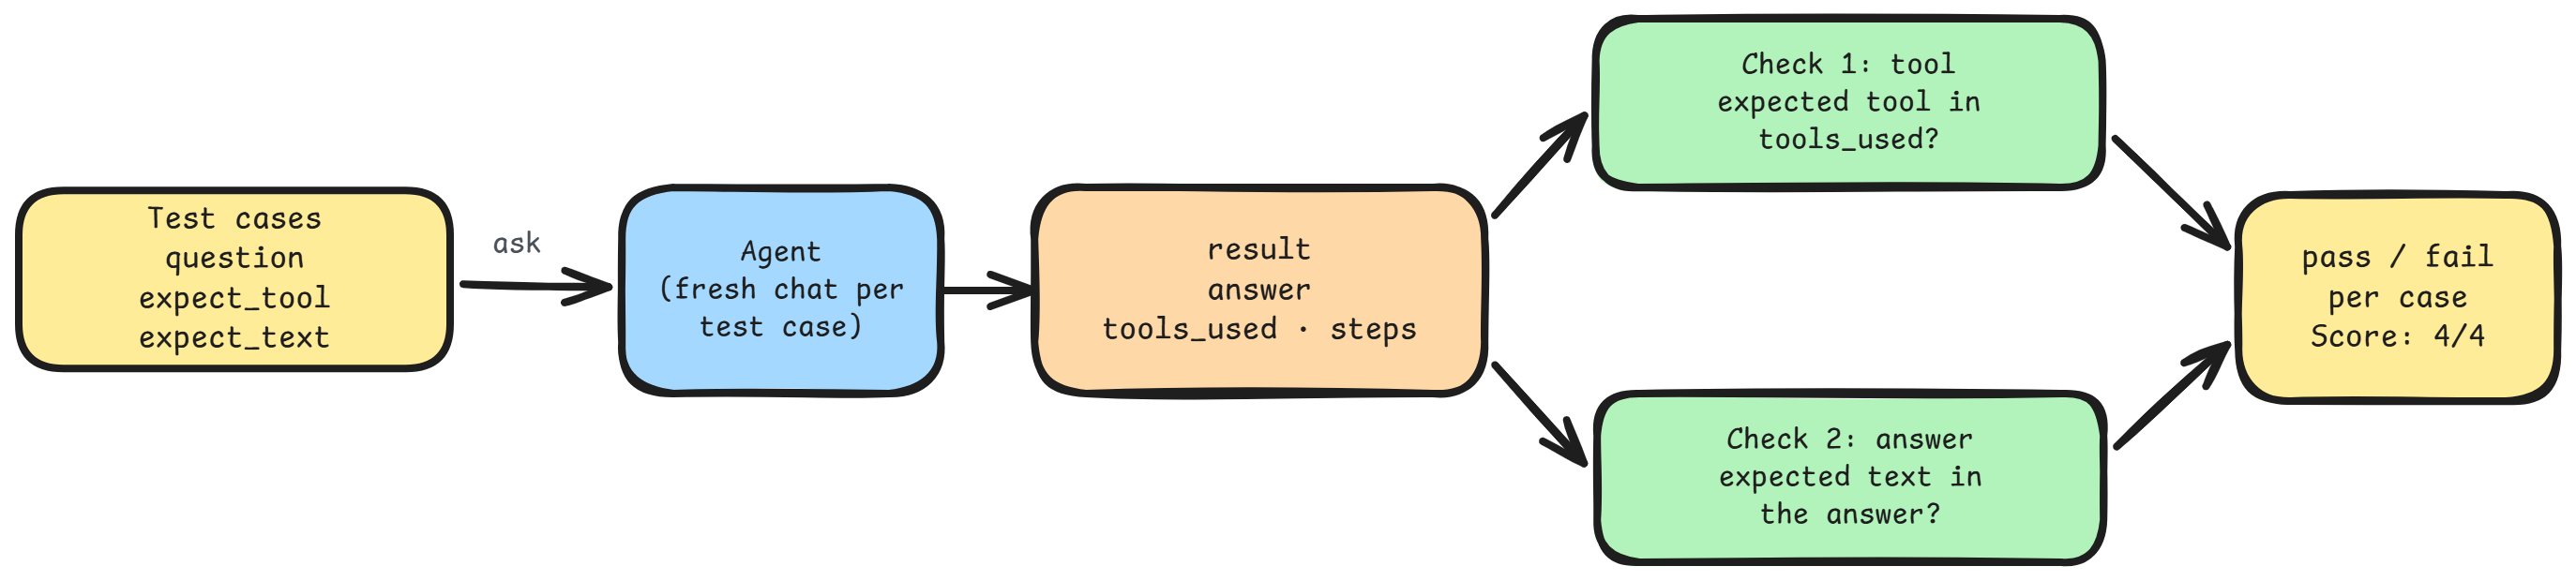

In [ ]:
EVAL_CASES = [
    {
        "question":    "What is 7391846 * 58213947?",
        "expect_tool": "calculator",
        "expect_text": "430308531276162",
    },
    {
        "question":    "What's the weather in Tokyo?",
        "expect_tool": "get_weather",
        "expect_text": "22",
    },
    {
        "question":    "Which is hotter right now, London or Pune?",
        "expect_tool": "get_weather",
        "expect_text": "pune",
    },
    {
        "question":    "Say hello in one short sentence.",
        "expect_tool": None,           # None = no tool should be used
        "expect_text": "",
    },
]

print(f"✅ {len(EVAL_CASES)} test cases ready")

✅ 4 test cases ready


In [ ]:
def run_evals(cases, run_fn):
    passed = 0
    for case in cases:
        result = run_fn(case["question"])

        # Did it use the right tool? (or no tool, when None is expected)
        if case["expect_tool"] is None:
            tool_ok = result["tools_used"] == []
        else:
            tool_ok = case["expect_tool"] in result["tools_used"]

        # Does the answer contain the expected text? (ignore case and commas)
        answer  = result["answer"].lower().replace(",", "")
        text_ok = case["expect_text"] in answer

        ok      = tool_ok and text_ok
        passed += ok
        print(f"{'✅' if ok else '❌'} {case['question']} - {answer}")
        if not tool_ok:
            print(f"     tool problem: expected {case['expect_tool']}, got {result['tools_used']}")
        if not text_ok:
            print(f"     answer missing: '{case['expect_text']}'")

    print(f"\nScore: {passed}/{len(cases)}")

In [ ]:
def basic_agent(question):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": question},
    ]
    return run_agent(messages, TOOLS, verbose=False)

In [ ]:
run_evals(EVAL_CASES, basic_agent)

✅ What is 7391846 * 58213947? - 430308531276162
✅ What's the weather in Tokyo? - tokyo: 22 °c clear.
✅ Which is hotter right now, London or Pune? - pune is hotter right now (28 °c) compared to london (15 °c).
✅ Say hello in one short sentence. - hello!

Score: 4/4
